# BERTopic - Vibecoding Tweet Topic Modeling

Notebook ini menjalankan BERTopic pada dataset tweet vibecoding yang sama dengan FASTopic
(`preprocessed_new_vibe_coding_tweets.csv`) supaya hasilnya bisa dibandingkan apple-to-apple.

**Pipeline BERTopic:** sentence embedding (MiniLM) -> UMAP dim reduction -> HDBSCAN clustering ->
c-TF-IDF untuk ekstraksi topic words. Berbeda dengan FASTopic (model probabilistik dengan
transport-plan loss), BERTopic adalah pipeline diskrit berbasis clustering.

In [46]:
!pip install topmost
!pip install bertopic

In [47]:
import pandas as pd
import numpy as np
import random
import torch
from bertopic import BERTopic

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Dataset SAMA persis dengan FASTopic notebook -> hasil dapat dibandingkan langsung.
df_preprocessed = pd.read_csv(r"/content/preprocessed_tweets.csv")
print(f"Total dokumen: {len(df_preprocessed)}")
df_preprocessed.head()

Total dokumen: 35159


,full_text,image_url,created_at,tweet_url,id_str
0,saw guy coding today tab chatgpt gemini claude...,NaN,April 2025,https://x.com/Yuchenj_UW/status/19165377865194...,1916537786519425124
1,imagine way thinking edge taste strategy could...,https://pbs.twimg.com/amplify_video_thumb/1919...,May 2025,https://x.com/FractionAI_xyz/status/1919796178...,1919796178033483801
2,guy one kenya best brains know introducing joh...,https://pbs.twimg.com/media/G1wuNGRXAAE8RBi.jpg,September 2025,https://x.com/onjolo_kenya/status/197150154911...,1971501549110141021
3,know funny people hear pope leo xiv math degre...,https://pbs.twimg.com/media/GqyT_bsXQAAzDiI.jpg,May 2025,https://x.com/SecretFire79/status/192207386337...,1922073863376011765
4,people today discouraging others learning prog...,NaN,March 2025,https://x.com/AndrewYNg/status/190021911682210...,1900219116822102116


In [48]:
docs = df_preprocessed['full_text'].fillna('').tolist()
docs = (
    df_preprocessed["full_text"]
    .fillna("")
    .str.replace(r"\bapps\b", "app", regex=True, case=False)
    .str.replace(r"\bbuilding\b", "build", regex=True, case=False)
    .tolist()
)

images = df_preprocessed['image_url'].tolist()
timestamps = df_preprocessed['created_at'].tolist()
ids = df_preprocessed['id_str'].tolist()
tweet_urls = df_preprocessed['tweet_url'].tolist()

for i in range(len(images)):
    if pd.isna(images[i]):
        images[i] = None

# JANGAN shuffle docs supaya index assignment tetap traceable ke dataframe asli.
print(f"Sample doc[0]: {docs[0][:120]}")

Sample doc[0]: saw guy coding today tab chatgpt gemini claude grok deepseek asked every exact question patiently waited pasted response


## Evaluation Setup

Memakai `topmost.Preprocess` HANYA untuk membangun reference corpus + vocabulary yang
identik dengan FASTopic & Top2Vec. Ini penting supaya skor coherence bisa dibandingkan
secara fair antar model (gensim `CoherenceModel` butuh dictionary yang konsisten).

Tiga metric yang dipakai:
- **C_v** — PMI berbasis sliding window + cosine similarity. Range ~0-1. Metric default di literatur BERTopic.
- **C_npmi** — Normalized PMI. Range ~[-1, 1] (~0.05-0.20 untuk tweet). Dipakai di paper FASTopic.
- **Topic diversity** — proporsi kata unik di seluruh top words antar topik. Range 0-1.

In [49]:
from topmost import Preprocess
from topmost.eva import _coherence, _diversity

# Stopwords config IDENTIK dengan FASTopic notebook.
domain_stopwords = ["vibecoding", "vibecode", "vibecoded", "vibe", "vibes"]
generic_stopwords = [
    "code", "coding", "like", "get"
]

shared_preprocess = Preprocess(
    stopwords=domain_stopwords + generic_stopwords,
)

prep_result = shared_preprocess.preprocess(docs)
ref_corpus = prep_result['train_texts']
ref_vocab = prep_result['vocab']
print(f"Reference corpus: {len(ref_corpus)} docs | vocab: {len(ref_vocab)} terms")

parsing texts: 100%|██████████| 35159/35159 [00:02<00:00, 12120.75it/s]
2026-06-23 06:36:53,492 - TopMost - Real vocab size: 28660
2026-06-23 06:36:53,498 - TopMost - Real training size: 35159 	 avg length: 15.967


Reference corpus: 35159 docs | vocab: 28660 terms


In [50]:
def evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10):
    """Hitung c_v coherence, c_npmi coherence, dan topic diversity.

    top_words: List[str] di mana tiap string = top words satu topik dipisah spasi.
    """
    truncated = [' '.join(tw.split()[:topn]) for tw in top_words]
    cv = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_v', topn=topn)
    npmi = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_npmi', topn=topn)
    td = _diversity(truncated)
    return {'c_v': cv, 'c_npmi': npmi, 'diversity': td}


def bertopic_top_words(topic_model, topn=15):
    """Ekstrak top words per topic dari BERTopic, exclude outlier topic (-1).
    Output: List[str] dengan format yang sama dengan FASTopic top_words.
    """
    topics = topic_model.get_topics()
    sorted_ids = sorted([tid for tid in topics.keys() if tid != -1])
    return [' '.join([w for w, _ in topics[tid][:topn]]) for tid in sorted_ids]

## BERTopic Config Rationale

- **Embedding model**: `all-MiniLM-L6-v2` -> SAMA dengan FASTopic untuk fairness.
- **`min_topic_size`=50**: Default 10 menghasilkan ratusan micro-topic pada 16k tweets.
  50 lebih sehat untuk corpus segini (mirip threshold yang dipakai paper BERTopic untuk Twitter).
- **`vectorizer_model` shared vocab**: CountVectorizer dipaksa pakai `ref_vocab` yang sama
  dengan FASTopic supaya c-TF-IDF beroperasi di vocabulary yang identik. Ini memastikan
  `evaluate_topics()` jalan dengan dictionary yang konsisten.
- **Pre-compute embeddings sekali**: kita encode semua dokumen sekali lalu reuse untuk tiap K
  di sweep -> hemat ~30 detik per K.

In [51]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# Pre-compute embeddings SEKALI -> reuse di setiap fit BERTopic untuk hemat waktu.
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device="cuda" if torch.cuda.is_available() else "cpu")
doc_embeddings = embed_model.encode(docs, show_progress_bar=True, batch_size=64)
print(f"Embeddings shape: {doc_embeddings.shape}")

# Vectorizer dengan vocab yang sama dengan FASTopic ref_vocab.
shared_vectorizer = CountVectorizer(vocabulary=ref_vocab)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/550 [00:00<?, ?it/s]

Embeddings shape: (35159, 384)


## K-Sweep via `nr_topics`

BERTopic awalnya menghasilkan banyak topik dari HDBSCAN, lalu `nr_topics=K` akan otomatis
menggabungkan topik termirip sampai jumlahnya = K. Ini setara dengan K-sweep di FASTopic.

Catatan: BERTopic kadang menghasilkan jumlah topik **lebih kecil** dari target K kalau
HDBSCAN tidak menemukan cukup cluster valid. Karena itu kita track `K_target` (yang diminta)
dan `K_actual` (yang dihasilkan).

In [52]:
K_VALUES = [8, 12, 15, 20, 25]
sweep_results = []

for k in K_VALUES:
    print(f"\n=== Training BERTopic with nr_topics={k} ===")
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    bt = BERTopic(
        embedding_model=embed_model,
        vectorizer_model=shared_vectorizer,
        nr_topics=k,
        calculate_probabilities=False,
        verbose=False,
    )
    bt.fit(docs, embeddings=doc_embeddings)
    tw = bertopic_top_words(bt, topn=10)
    metrics = evaluate_topics(tw, ref_corpus, ref_vocab, topn=10)
    metrics['K_target'] = k
    metrics['K_actual'] = len(tw)
    sweep_results.append(metrics)
    print(f"  target={k} actual={len(tw)}  c_v={metrics['c_v']:.4f}  c_npmi={metrics['c_npmi']:.4f}  diversity={metrics['diversity']:.4f}")
    del bt

sweep_df = pd.DataFrame(sweep_results)[['K_target', 'K_actual', 'c_v', 'c_npmi', 'diversity']]
sweep_df['combined'] = ((sweep_df['c_v'] + (sweep_df['c_npmi'] + 1) / 2) / 2) * sweep_df['diversity']
sweep_df.sort_values('combined', ascending=False)


=== Training BERTopic with nr_topics=8 ===


/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


  target=8 actual=7  c_v=0.4425  c_npmi=-0.0260  diversity=0.9857

=== Training BERTopic with nr_topics=12 ===


/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


  target=12 actual=11  c_v=0.4699  c_npmi=0.0058  diversity=0.9000

=== Training BERTopic with nr_topics=15 ===


...

/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


  target=20 actual=19  c_v=0.4995  c_npmi=0.0286  diversity=0.9105

=== Training BERTopic with nr_topics=25 ===


/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


  target=25 actual=24  c_v=0.5303  c_npmi=0.0434  diversity=0.8917


,K_target,K_actual,c_v,c_npmi,diversity,combined
4,25,24,0.530316,0.043430,0.891667,0.469031
3,20,19,0.499469,0.028565,0.910526,0.461524
0,8,7,0.442522,-0.025960,0.985714,0.458131
1,12,11,0.469872,0.005753,0.900000,0.437737
2,15,14,0.452849,-0.007288,0.892857,0.423752


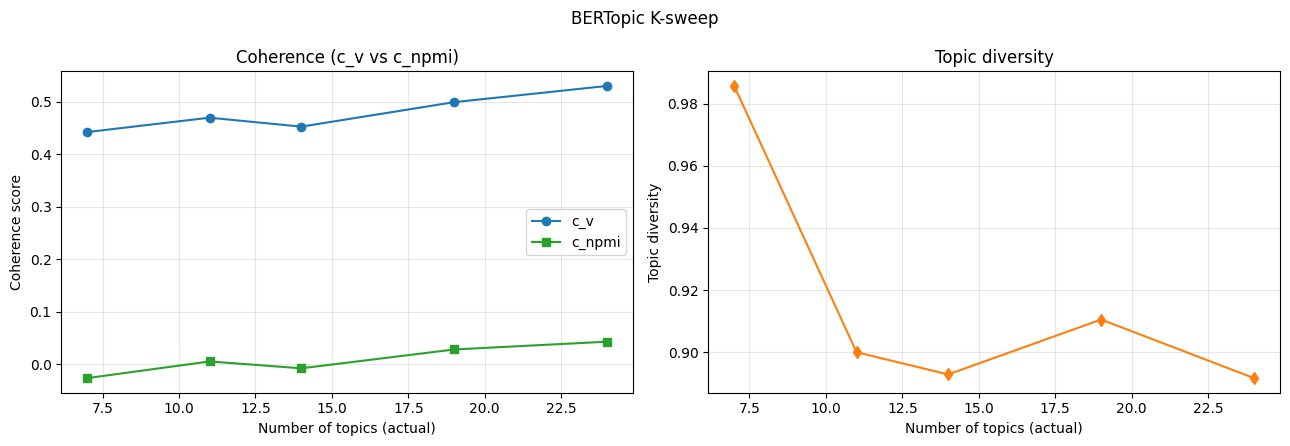


Rekomendasi nr_topics (max combined score): 25
Override manual jika perlu dengan mengubah NUM_TOPICS di cell training di bawah.


In [53]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax1 = axes[0]
ax1.plot(sweep_df['K_actual'], sweep_df['c_v'], 'o-', color='tab:blue', label='c_v')
ax1.plot(sweep_df['K_actual'], sweep_df['c_npmi'], 's-', color='tab:green', label='c_npmi')
ax1.set_xlabel('Number of topics (actual)')
ax1.set_ylabel('Coherence score')
ax1.set_title('Coherence (c_v vs c_npmi)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(sweep_df['K_actual'], sweep_df['diversity'], 'd-', color='tab:orange')
ax2.set_xlabel('Number of topics (actual)')
ax2.set_ylabel('Topic diversity')
ax2.set_title('Topic diversity')
ax2.grid(alpha=0.3)

plt.suptitle('BERTopic K-sweep')
fig.tight_layout()
plt.show()

best_idx = sweep_df['combined'].idxmax()
best_k = int(sweep_df.loc[best_idx, 'K_target'])
print(f"\nRekomendasi nr_topics (max combined score): {best_k}")
print("Override manual jika perlu dengan mengubah NUM_TOPICS di cell training di bawah.")

## Final Model

In [54]:
NUM_TOPICS = 25
print(f"Training final BERTopic with nr_topics={NUM_TOPICS}")

np.random.seed(SEED)
torch.manual_seed(SEED)

model = BERTopic(
    embedding_model=embed_model,
    vectorizer_model=shared_vectorizer,
    nr_topics=NUM_TOPICS,
    calculate_probabilities=True,
    verbose=True,
)
topics, probs = model.fit_transform(docs, embeddings=doc_embeddings)

top_words = bertopic_top_words(model, topn=15)
final_metrics = evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10)
print(
    f"\nFinal BERTopic | target K={NUM_TOPICS}  actual={len(top_words)}"
    f"  c_v={final_metrics['c_v']:.4f}"
    f"  c_npmi={final_metrics['c_npmi']:.4f}"
    f"  diversity={final_metrics['diversity']:.4f}\n"
)
for i, tw in enumerate(top_words):
    print(f"Topic {i}: {tw}")

bertopic_metrics = {**final_metrics, 'model': 'BERTopic', 'K': len(top_words)}

2026-06-23 06:40:44,005 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Training final BERTopic with nr_topics=25


2026-06-23 06:41:14,971 - BERTopic - Dimensionality - Completed ✓
2026-06-23 06:41:14,974 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-23 06:42:58,302 - BERTopic - Cluster - Completed ✓
2026-06-23 06:42:58,303 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
2026-06-23 06:42:58,932 - BERTopic - Representation - Completed ✓
2026-06-23 06:42:58,933 - BERTopic - Topic reduction - Reducing number of topics
2026-06-23 06:42:58,989 - BERTopic - Representation - Fine-tuning topics using representation models.
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
2026-06-23 06:42:59,501 - BERTopic - Representation - Completed ✓
2026-06-23 06:42:59,506


Final BERTopic | target K=25  actual=24  c_v=0.5142  c_npmi=0.0324  diversity=0.8875

Topic 0: app cursor build game new claude one using time agent
Topic 1: llm agents agent build create tools using without one needed
Topic 2: blockchain meme decentralized crypto data storage web chain build powered
Topic 3: python machine learning books data science programming free beginners learn
Topic 4: openai gpt models model codex open windsurf chatgpt new anthropic
Topic 5: layoffs jobs tech mgx market company engineers team india job
Topic 6: neural networks deep learning network reinforcement lstm recurrent series forecasting
Topic 7: robotics skills students school digital education future schools learning kids
Topic 8: deepseek reasoning model math alphaevolve models chinese open world deepmind
Topic 9: doctors healthcare practice health medical practices doctor care services private
Topic 10: grok openrouter xai reasoning elon gpqa scicode traffic musk fast
Topic 11: apple caffeine anthr

In [55]:
new_topics = model.reduce_outliers(docs, topics)

100%|██████████| 22/22 [00:02<00:00,  7.61it/s]


In [57]:
# Topic info table dari built-in BERTopic
topic_info = model.get_topic_info()
topic_info.head(19)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,21124,-1_build_app_new_tools,"[build, app, new, tools, one, agents, time, re...",[biggest lie tech build come sad truth builder...
1,0,6908,0_app_cursor_build_game,"[app, cursor, build, game, new, claude, one, u...",[think ever much fun vibecoding making mobile ...
2,1,4485,1_llm_agents_agent_build,"[llm, agents, agent, build, create, tools, usi...",[agent forge officially live changing game bui...
3,2,598,2_blockchain_meme_decentralized_crypto,"[blockchain, meme, decentralized, crypto, data...",[got meme idea make token smart contract gener...
4,3,336,3_python_machine_learning_books,"[python, machine, learning, books, data, scien...","[machine learning engineering python, best mac..."
5,4,283,4_openai_gpt_models_model,"[openai, gpt, models, model, codex, open, wind...","[openai launches codex coding agent chatgpt, o..."
6,5,190,5_layoffs_jobs_tech_mgx,"[layoffs, jobs, tech, mgx, market, company, en...",[build entire software team without hiring any...
7,6,153,6_neural_networks_deep_learning,"[neural, networks, deep, learning, network, re...","[essentials deep learning neural networks, too..."
8,7,153,7_robotics_skills_students_school,"[robotics, skills, students, school, digital, ...",[imagine transforming students confident innov...
9,8,140,8_deepseek_reasoning_model_math,"[deepseek, reasoning, model, math, alphaevolve...",[research released exaone deep reasoning model...


In [58]:
model.update_topics(docs, topics=new_topics, vectorizer_model=shared_vectorizer)

2026-06-23 06:43:41,301 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


In [64]:
# Topic info table dari built-in BERTopic
topic_info = model.get_topic_info()
topic_info.head(25)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,4,-1_sakin_vibeinvesting_amper_vibesecuritiesfraud,"[sakin, vibeinvesting, amper, vibesecuritiesfr...",[biggest lie tech build come sad truth builder...
1,0,15786,0_app_build_one_new,"[app, build, one, new, time, people, claude, u...",[think ever much fun vibecoding making mobile ...
2,1,8665,1_agents_llm_build_agent,"[agents, llm, build, agent, create, tools, wit...",[agent forge officially live changing game bui...
3,2,2330,2_blockchain_web_decentralized_crypto,"[blockchain, web, decentralized, crypto, chain...",[got meme idea make token smart contract gener...
4,3,870,3_python_machine_learning_science,"[python, machine, learning, science, data, pro...","[machine learning engineering python, best mac..."
5,4,745,4_openai_gpt_models_model,"[openai, gpt, models, model, codex, claude, an...","[openai launches codex coding agent chatgpt, o..."
6,5,1222,5_jobs_tech_market_company,"[jobs, tech, market, company, companies, engin...",[build entire software team without hiring any...
7,6,406,6_deep_neural_networks_learning,"[deep, neural, networks, learning, network, se...","[essentials deep learning neural networks, too..."
8,7,776,7_skills_digital_students_education,"[skills, digital, students, education, robotic...",[imagine transforming students confident innov...
9,8,663,8_reasoning_deepseek_model_math,"[reasoning, deepseek, model, math, open, model...",[research released exaone deep reasoning model...


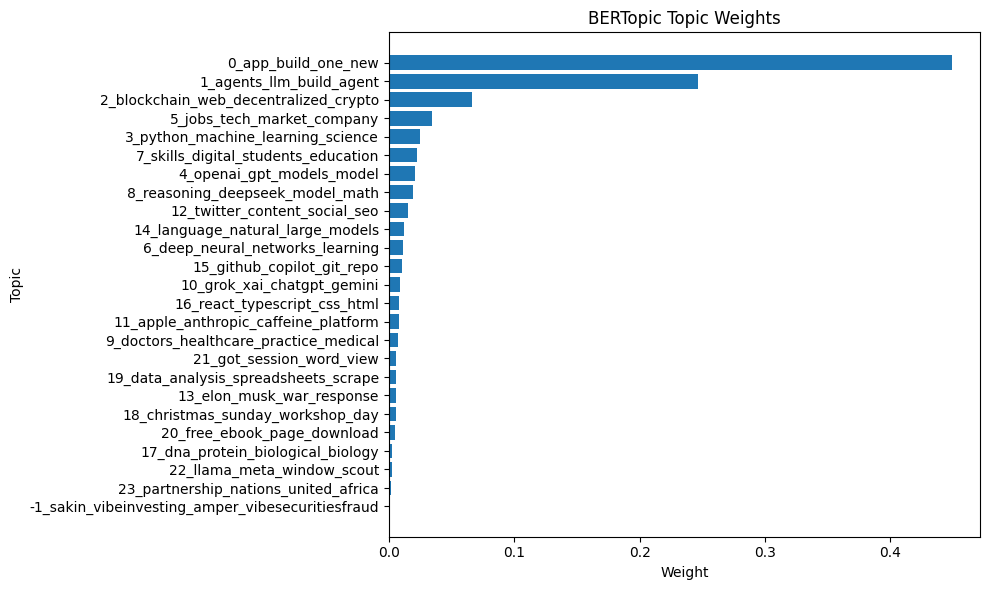

In [73]:
import matplotlib.pyplot as plt

topic_info["Weight"] = (
    topic_info["Count"] / topic_info["Count"].sum()
)

plot_df = topic_info.sort_values("Weight", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["Name"], plot_df["Weight"])

plt.xlabel("Weight")
plt.ylabel("Topic")
plt.title("BERTopic Topic Weights")

plt.tight_layout()
plt.show()

In [65]:
# Intertopic distance map
fig = model.visualize_topics()
fig.show()

In [66]:
fig_heatmap = model.visualize_heatmap()
fig_heatmap.show()

In [67]:
# Top words per topic dengan c-TF-IDF weights
fig = model.visualize_barchart(top_n_topics=NUM_TOPICS, n_words=20)
fig.show()

In [68]:
# Hierarchical view
fig = model.visualize_hierarchy()
fig.show()

In [69]:
# Sample tweets per topic untuk inspeksi kualitatif
def sample_docs_for_topic(topic_id, n=3):
    idx = [i for i, t in enumerate(topics) if t == topic_id]
    if not idx:
        return []
    pick = np.random.choice(idx, size=min(n, len(idx)), replace=False)
    return [docs[i] for i in pick]

# Skip outlier topic -1, ambil top 10 berdasarkan size
non_outlier = topic_info[topic_info['Topic'] != -1].head(24)
for _, row in non_outlier.iterrows():
    tid = row['Topic']
    print(f"\n=== Topic {tid} | size={row['Count']} | {row['Name'][:80]} ===")
    for s in sample_docs_for_topic(tid, n=3):
        print(" -", s[:200])


=== Topic 0 | size=15786 | 0_app_build_one_new ===
 - heard vibecoding life never vibe lyric dey sing
 - software engineering dead grown vibecoding agents
 - version coming vibecoding real adrenaline

=== Topic 1 | size=8665 | 1_agents_llm_build_agent ===
 - build agents automation workflows real projects public sharing actually works coding systems career lessons follow like practical tech hype
 - community fraction important technology every user brings new strategies styles coding fresh ideas together make ecosystem richer wish tell fellow fapper best comparison
 - spent today diving next app idea coding

=== Topic 2 | size=2330 | 2_blockchain_web_decentralized_crypto ===
 - market events mindshare news mit incubated raised seed round led build web first decentralized memory layer aiming solve blockchain scalability random linear network coding rlnc
 - private market fundraising tracker getting users per week many posthog session replays watch currently using claude code mcp unders

## Topic over Time

Memvisualisasikan evolusi topik sepanjang waktu memakai kolom `created_at` dari dataset
sumber (`vibe_coding_combined_translated.csv`). File preprocessed tidak menyimpan timestamp,
jadi `created_at` direkonstruksi dengan menjalankan ulang pipeline preprocessing yang **identik**
dengan `preprocess_new.ipynb` (decode HTML -> lowercase -> hapus URL/mention/hashtag ->
normalisasi "vibe coding" -> tokenize -> buang stopword + token <=2 char -> filter dokumen
>= 4 token). Karena pipeline ini deterministik & mempertahankan urutan baris, hasilnya selaras
per-posisi dengan `docs` (BERTopic TIDAK men-shuffle docs, sehingga mapping langsung 1:1).

In [70]:
# Hitung representasi topik per bin waktu. Data span ~13 bulan -> nr_bins=13 (~bulanan).
# BERTopic me-recompute c-TF-IDF per bin memakai topik global yang sudah di-fit.
topics_over_time = model.topics_over_time(docs, timestamps, nr_bins=13)
topics_over_time.head()

12it [00:02,  5.44it/s]


,Topic,Words,Frequency,Timestamp
0,-1,"vibemanaging, vibeinvesting, vibesecuritiesfra...",1,2025-01-31 15:14:24
1,0,"app, build, cursor, new, game",2653,2025-01-31 15:14:24
2,1,"agents, llm, build, agent, create",1186,2025-01-31 15:14:24
3,2,"blockchain, crypto, powered, decentralized, chain",309,2025-01-31 15:14:24
4,3,"python, machine, learning, programming, data",185,2025-01-31 15:14:24


In [71]:
# Visualisasi frekuensi topik sepanjang waktu (outlier -1 otomatis di-exclude).
fig = model.visualize_topics_over_time(topics_over_time, top_n_topics=NUM_TOPICS)

# Pindahkan legend ke bawah graph (horizontal) supaya area plot lebih lebar.
fig.update_layout(
    legend=dict(
        orientation="h",      # legend mendatar
        yanchor="top",
        y=-0.20,              # di bawah area plot (negatif = di luar bawah)
        xanchor="center",
        x=0.5,
        title_text="",
    ),
    margin=dict(b=160),       # ruang ekstra di bawah untuk menampung legend
)
fig.show()